#  Customer Spending Category Classifier
**Task ID:** ML-1 | **Domain:** Machine Learning | **Level:** Beginner

---
###  What are we doing?
We want to teach a computer to look at a bank transaction description like:
- `"McDonald's dinner"` → **Dining**
- `"Uber ride to airport"` → **Transport**
- `"Netflix monthly subscription"` → **Entertainment**

This is called **Text Classification** — a type of Machine Learning.

---

##  Step 1: Import Libraries
Think of libraries as tool boxes. We import only what we need.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
#  Basic tools
import pandas as pd           # For working with tables (like Excel)
import numpy as np            # For numbers and math
import re                     # For cleaning text (regex)
import warnings
warnings.filterwarnings('ignore')

#  Machine Learning tools
from sklearn.model_selection import train_test_split       # Split data into train & test
from sklearn.feature_extraction.text import TfidfVectorizer # Convert text to numbers
from sklearn.naive_bayes import MultinomialNB              # Model 1: Naive Bayes
from sklearn.linear_model import LogisticRegression        # Model 2: Logistic Regression
from sklearn.ensemble import RandomForestClassifier        # Model 3: Random Forest
from sklearn.metrics import (
    accuracy_score,           # How often we are correct
    confusion_matrix,         # Table showing mistakes
    classification_report     # Detailed per-class scores
)

#  Visualization tools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

print(" All libraries imported successfully!")

 All libraries imported successfully!


 ##  Step 2: Create the Dataset
We'll create our own labeled dataset with transaction descriptions and their categories.

> **Note:** In real projects, you'd load a CSV file. Here we build it ourselves so you understand the structure.

In [24]:
# -----------------------------------------------
#  Our transaction data
# Each entry has: a description and a category label
# -----------------------------------------------

data = pd.read_csv('data.csv')

# Create a DataFrame (like an Excel table)
df = pd.DataFrame(data)

print(f" Dataset created!")
print(f" Total records: {len(df)}")
print(f" Categories: {df['category'].unique().tolist()}")
print()
print("First 5 rows:")
df.head()


 Dataset created!
 Total records: 912
 Categories: ['Shopping', 'Transport', 'Health', 'Groceries', 'Utilities', 'Entertainment', 'Dining', 'Education']

First 5 rows:


,description,category
0,Doll set purchase,Shopping
1,City bus daily fare,Transport
2,Meal prep service health,Health
3,Mango seasonal buy,Groceries
4,Frozen vegetables pack,Groceries


##  Step 3: Data Preprocessing (Cleaning the Text)
Computers struggle with messy text. We clean it first:
- Make everything **lowercase** (so "Uber" and "uber" are treated the same)
- Remove **special characters** (punctuation, symbols)
- Remove extra **spaces**

In [25]:
def clean_text(text):
    """
    Cleans a transaction description.
    Input:  'McDonald\'s Dinner!!'
    Output: 'mcdonalds dinner'
    """
    # Step 1: Make lowercase
    text = text.lower()

    # Step 2: Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Remove extra spaces
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    return text


# Apply the cleaning function to all descriptions
df['cleaned'] = df['description'].apply(clean_text)

# Show before vs after
print(" Before and After Cleaning:")
print("-" * 55)
for i in range(5):
    print(f"Original : {df['description'][i]}")
    print(f"Cleaned  : {df['cleaned'][i]}")
    print()

print(f" Total cleaned: {len(df)} descriptions")
print()
print("Sample of full dataframe:")
df[['description', 'cleaned', 'category']].head(10)


 Before and After Cleaning:
-------------------------------------------------------
Original : Doll set purchase
Cleaned  : doll set purchase

Original : City bus daily fare
Cleaned  : city bus daily fare

Original : Meal prep service health
Cleaned  : meal prep service health

Original : Mango seasonal buy
Cleaned  : mango seasonal buy

Original : Frozen vegetables pack
Cleaned  : frozen vegetables pack

 Total cleaned: 912 descriptions

Sample of full dataframe:


,description,cleaned,category
0,Doll set purchase,doll set purchase,Shopping
1,City bus daily fare,city bus daily fare,Transport
2,Meal prep service health,meal prep service health,Health
3,Mango seasonal buy,mango seasonal buy,Groceries
4,Frozen vegetables pack,frozen vegetables pack,Groceries
5,Smart meter electricity,smart meter electricity,Utilities
6,Heritage walk tour,heritage walk tour,Entertainment
7,Stationery set kids,stationery set kids,Shopping
8,Billiards parlour,billiards parlour,Entertainment
9,Street cart payment,street cart payment,Dining


## Step 4: Explore the Data (EDA)
Always look at your data before training. Check if categories are balanced.

 Records per category:
category
Shopping         114
Transport        114
Health           114
Groceries        114
Utilities        114
Entertainment    114
Dining           114
Education        114
Name: count, dtype: int64



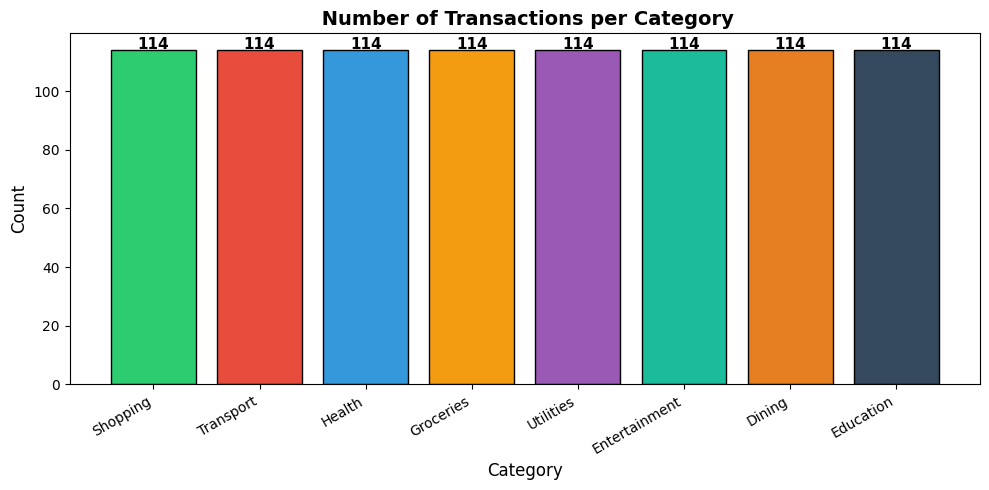

 Distribution looks balanced — good for training!


In [26]:
# Count records per category
category_counts = df['category'].value_counts()
print(" Records per category:")
print(category_counts)
print()

# Plot the distribution
plt.figure(figsize=(10, 5))
colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']
bars = plt.bar(category_counts.index, category_counts.values, color=colors, edgecolor='black')

# Add count labels on bars
for bar, count in zip(bars, category_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(count), ha='center', fontweight='bold', fontsize=11)

plt.title(' Number of Transactions per Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150)
plt.show()
print(" Distribution looks balanced — good for training!")

##  Step 5: Feature Extraction (Text → Numbers)

>


ML models can't understand words — they only understand numbers.

**TF-IDF** converts each description into a vector of numbers based on word importance.
> Think of it as: more unique and frequent a word is → higher score

In [28]:
# TF-IDF = Term Frequency × Inverse Document Frequency
# ngram_range=(1,2) means we look at single words AND pairs of words
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # Use 1-word and 2-word combinations (bonus: n-grams!)
    max_features=500,    # Use top 5000 most important features
    sublinear_tf=True      # frequency scaling better karta hai
)

# X = features (the descriptions as numbers)
# y = labels  (the categories)
X = vectorizer.fit_transform(df['cleaned'])
y = df['category']

print(f"Feature extraction done!")
print(f" Matrix shape: {X.shape}")
print(f"{X.shape[0]} transactions, {X.shape[1]} features (words/phrases)")

Feature extraction done!
 Matrix shape: (912, 500)
912 transactions, 500 features (words/phrases)


## ✂️ Step 6: Train / Test Split
We split our data:
- **80% Training** → the model learns from this
- **20% Testing** → we test it on unseen data (like a final exam!)

In [29]:
# Split: 80% train, 20% test
# random_state=42 makes the split reproducible (same result every run)
# stratify=y ensures each category has the same proportion in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data split complete!")
print(f"Training samples : {X_train.shape[0]}")
print(f" Testing  samples : {X_test.shape[0]}")
print()
print("Category distribution in test set:")
print(y_test.value_counts())

Data split complete!
Training samples : 729
 Testing  samples : 183

Category distribution in test set:
category
Entertainment    23
Transport        23
Health           23
Dining           23
Groceries        23
Utilities        23
Shopping         23
Education        22
Name: count, dtype: int64


##  Step 7: Train & Compare All Three Models
We'll train all 3 required models and compare which performs best.

| Model | How it works (simple) |
|---|---|
| **Naive Bayes** | Counts word frequencies per category and guesses |
| **Logistic Regression** | Finds a mathematical boundary between categories |
| **Random Forest** | Uses many decision trees and votes on the answer |

In [30]:
# Define all three models
models = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}  # Store accuracy for each model

print(" Training all models...\n")
print("-" * 40)

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'predictions': y_pred, 'accuracy': acc}

    print(f" {name}")
    print(f"   Accuracy: {acc * 100:.1f}%")
    print()

# Find the best model
best_name = max(results, key=lambda k: results[k]['accuracy'])
print("-" * 40)
print(f" Best Model: {best_name} ({results[best_name]['accuracy']*100:.1f}%)")

 Training all models...

----------------------------------------
 Naive Bayes
   Accuracy: 79.8%

 Logistic Regression
   Accuracy: 81.4%

 Random Forest
   Accuracy: 67.2%

----------------------------------------
 Best Model: Logistic Regression (81.4%)


##  Step 8: Model Comparison Chart (Bonus)

---



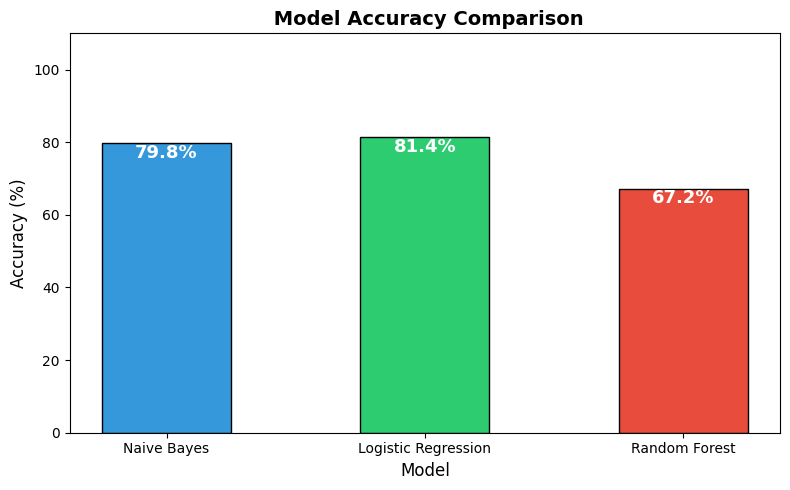

In [31]:
model_names = list(results.keys())
accuracies  = [results[n]['accuracy'] * 100 for n in model_names]
bar_colors  = ['#3498db', '#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=bar_colors, edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 4,
             f'{acc:.1f}%', ha='center', color='white', fontweight='bold', fontsize=13)

plt.ylim(0, 110)
plt.title(' Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

##  Step 9: Deep Evaluation of Best Model
Now we evaluate our best model in detail using:
1. **Accuracy** — overall correct %
2. **F1 Score per class** — per-category performance
3. **Confusion Matrix** — where the model gets confused

In [32]:
# Use best model's predictions
best_model   = results[best_name]['model']
y_pred_best  = results[best_name]['predictions']

print(f" Evaluation Report — {best_name}")
print("=" * 55)
print(f"Overall Accuracy: {results[best_name]['accuracy']*100:.2f}%")
print("=" * 55)
print()
print("Per-Class Performance:")
print("-" * 55)
print(classification_report(y_test, y_pred_best))

 Evaluation Report — Logistic Regression
Overall Accuracy: 81.42%

Per-Class Performance:
-------------------------------------------------------
               precision    recall  f1-score   support

       Dining       0.88      1.00      0.94        23
    Education       0.71      0.68      0.70        22
Entertainment       0.82      0.78      0.80        23
    Groceries       0.90      0.83      0.86        23
       Health       0.79      0.96      0.86        23
     Shopping       0.69      0.78      0.73        23
    Transport       0.88      0.61      0.72        23
    Utilities       0.87      0.87      0.87        23

     accuracy                           0.81       183
    macro avg       0.82      0.81      0.81       183
 weighted avg       0.82      0.81      0.81       183



###  Confusion Matrix
This table shows:
- **Diagonal** (top-left to bottom-right) = correct predictions
- **Off-diagonal** = mistakes  (row = true, column = predicted)

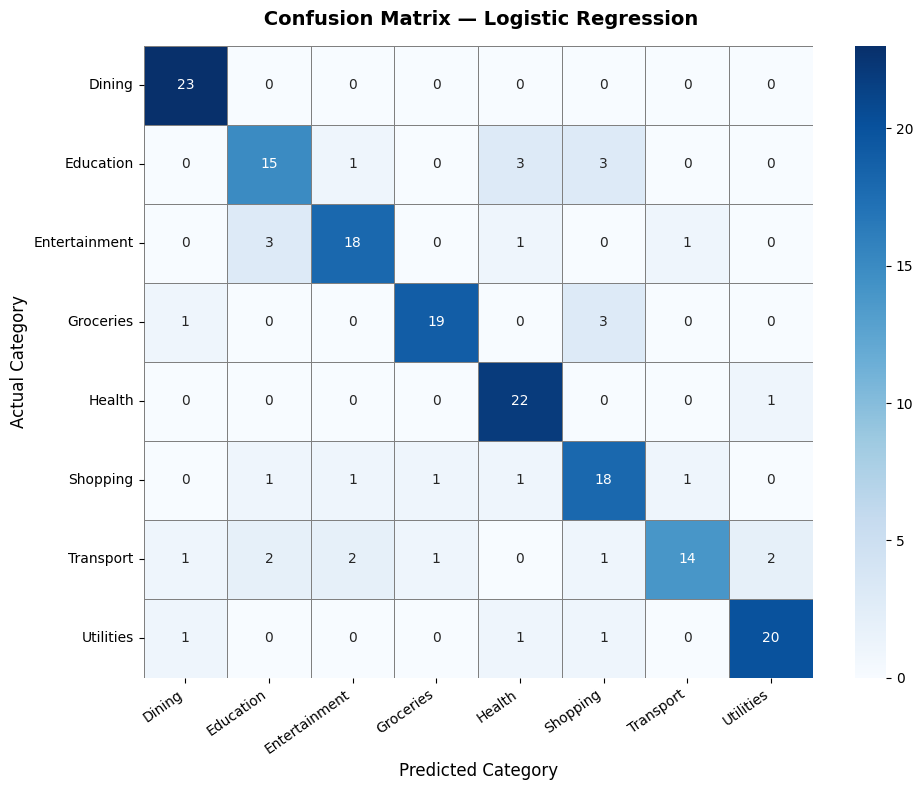

 Confusion matrix saved as confusion_matrix.png


In [33]:
# Get sorted category names
categories = sorted(df['category'].unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=categories)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=categories,
    yticklabels=categories,
    linewidths=0.5,
    linecolor='gray'
)
plt.title(f' Confusion Matrix — {best_name}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved as confusion_matrix.png")

##  Step 10: Error Analysis — Top 5 Misclassified Pairs
Find where the model makes the most mistakes.

In [34]:
# Collect all mistakes
errors = []

# y_test_list: actual labels, y_pred_best: what model predicted
for actual, predicted in zip(y_test, y_pred_best):
    if actual != predicted:
        # Store mistake as a tuple (actual, predicted)
        errors.append((actual, predicted))

# Count how often each mistake happens
from collections import Counter
error_counts = Counter(errors)

print(f" Total mistakes: {len(errors)}")
print()
print("Top 5 Most Common Misclassifications:")
print("-" * 50)

if error_counts:
    top5 = error_counts.most_common(5)
    for rank, ((actual, predicted), count) in enumerate(top5, 1):
        print(f"#{rank}  Actual: '{actual}' → Predicted: '{predicted}' ({count} times)")
else:
    print(" No mistakes! Perfect classifier on test set.")

print()
print(" Why do mistakes happen?")
print("   Some categories share similar words (e.g., 'gym' could be Health or Entertainment)")

 Total mistakes: 34

Top 5 Most Common Misclassifications:
--------------------------------------------------
#1  Actual: 'Entertainment' → Predicted: 'Education' (3 times)
#2  Actual: 'Education' → Predicted: 'Shopping' (3 times)
#3  Actual: 'Groceries' → Predicted: 'Shopping' (3 times)
#4  Actual: 'Education' → Predicted: 'Health' (3 times)
#5  Actual: 'Transport' → Predicted: 'Utilities' (2 times)

 Why do mistakes happen?
   Some categories share similar words (e.g., 'gym' could be Health or Entertainment)


## Step 11: Prediction System
Now the fun part — let's test our model with brand new inputs!
Just type any transaction description and it will predict the category.

In [36]:
def predict_category(description, model=None, vec=None):
    if model is None:
        model = best_model
    if vec is None:
        vec = vectorizer

    # Step 1: Clean the input
    cleaned = clean_text(description)

    # Step 2: Convert to TF-IDF numbers
    features = vec.transform([cleaned])

    # Step 3: Predict
    prediction = model.predict(features)[0]

    print(f"Transaction : '{description}'")
    print(f"Category    : {prediction}")
    print()
    return prediction


# ------------------------------------------------
# Prediction System — Test Results
# ------------------------------------------------
print("=" * 50)
print("Prediction System — Test Results")
print("=" * 50)
print()

test_inputs = [
    "Netflix subscription monthly",
    "Petrol station fuel refill",
    "Hospital doctor visit",
    "Daraz online shopping clothes",
    "Electricity bill payment",
    "Pizza Hut dinner",
    "Udemy python course",
    "Imtiaz grocery shopping"
]

for t in test_inputs:
    predict_category(t)

Prediction System — Test Results

Transaction : 'Netflix subscription monthly'
Category    : Entertainment

Transaction : 'Petrol station fuel refill'
Category    : Transport

Transaction : 'Hospital doctor visit'
Category    : Health

Transaction : 'Daraz online shopping clothes'
Category    : Shopping

Transaction : 'Electricity bill payment'
Category    : Utilities

Transaction : 'Pizza Hut dinner'
Category    : Dining

Transaction : 'Udemy python course'
Category    : Education

Transaction : 'Imtiaz grocery shopping'
Category    : Groceries



##  Step 12: Try Your Own Input!
Change the text below to any transaction you want to classify.

In [37]:
# ------------------------------------------------
# Interactive Prediction — User Input System
# ------------------------------------------------
print("=" * 50)
print("  Spending Category Predictor")
print("=" * 50)
print("Type 'exit' to quit\n")

while True:
    user_input = input("Enter transaction description: ").strip()

    if user_input.lower() == 'exit':
        print("Exiting predictor. Goodbye!")
        break

    if user_input == '':
        print("Please enter a description.\n")
        continue

    predict_category(user_input)

  Spending Category Predictor
Type 'exit' to quit

Enter transaction description: exit
Exiting predictor. Goodbye!
